# 07 · Kubernetes, GPU sharing (HAMi) and autoscaling (KEDA)

Phases 0 to 6 ran on Docker Compose. This phase moves the stack onto **Kubernetes (k3s)** and asks two operational questions:

1. **Can two models share one GPU?** HAMi slices a GPU between pods with memory (and optionally compute) limits. What does sharing cost the busy model, and does it hurt the quiet one?
2. **Can the cluster add GPUs when load rises?** KEDA scales the vLLM Deployment from 1 to 2 pods on the number of requests inside vLLM, and back down when load falls.

All numbers are read from `results/07_gpu_slicing_hami/`.

## Setup

* **Cluster:** one node, k3s with NVIDIA as the default container runtime; HAMi for GPU sharing; KEDA for autoscaling (`scripts/setup_k3s.sh`).
* **Stack as Kubernetes resources** (`scripts/k8s_manifests.py`): gateway (8 workers), NGINX (least connections to vLLM pods found through a headless Service), Prometheus (finds vLLM pods through the Kubernetes API), Grafana, Jaeger, GPU exporter.
* **Tenant A**: Qwen2.5-7B-Instruct, FP8 weights (the Phase 5 config), under Locust load through the gateway: 32 → 256 users.
* **Tenant B**: Qwen2.5-1.5B-Instruct, a latency-sensitive internal service: 4 clients sending short questions the whole time, starting 60 s before A's load.

| Scenario | GPUs | Tenant A | Tenant B |
|---|---|---|---|
| isolated | 2 | whole GPU 0 | whole GPU 1 |
| shared | 1 | GPU 0, 20,000 MB limit | GPU 0, 9,000 MB limit |
| shared_cores | 1 | GPU 0, 20,000 MB, 70% of cores | GPU 0, 9,000 MB, 30% of cores |
| autoscale | 1 → 2 | 1 to 2 pods, whole GPUs, KEDA | none |

## The cluster

```
                                   one k3s node (2× RTX 5090), NVIDIA as the default runtime
 Locust ──► gateway (NodePort 8080) ──► NGINX ──► headless Service vllm-large ──► vLLM pod(s), tenant A (7B FP8)
                                       least_conn          (DNS: one IP per pod)         ▲ KEDA adds a 2nd pod when
                                                                                         │ running + waiting > 180 per pod
 probe.py ──► NodePort 8001 ──────────────────────────────────────────────────────────► vLLM pod, tenant B (1.5B)

 HAMi scheduler     picks the GPU for each pod (pinned by GPU ID) and checks memory and core limits fit
 HAMi device plugin hands the pod its GPU slice; its CUDA hook enforces the memory limit (and core ceiling)
 Prometheus         finds vLLM pods through the Kubernetes API; scrapes gateway, GPU exporter and HAMi (31992, 31993)
 KEDA               reads the Prometheus query every 10 s and drives an HPA on the vllm-large Deployment
 Grafana, Jaeger    as in earlier phases (NodePorts 3000, 16686)
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = ROOT / "results" / "07_gpu_slicing_hami"
sys.path.insert(0, str(ROOT / "loadtest"))
from results_logger import load_runs

runs = load_runs("07_gpu_slicing_hami")
sweeps = {r["config"]["label"]: r for r in runs if r["name"].startswith("load_sweep_")}
tenants = {r["config"]["label"]: r for r in runs if r["name"].startswith("tenants_")}
timeline = next((r for r in reversed(runs) if r["name"] == "timeline_autoscale"), None)
print(f"sweeps: {sorted(sweeps)} | tenant analyses: {sorted(tenants)} | autoscale timeline: {bool(timeline)}")
for f in sorted(RESULTS.glob("*/failed.log")):
    print(f"DID NOT START: {f.parent.name}")

def v(d, *keys):
    for k in keys:
        d = (d or {}).get(k)
    return d

def cell(value, fmt, width, scale=1, unit=""):
    return ("-" if value is None else format(value * scale, fmt) + unit).rjust(width)

sweeps: ['isolated', 'shared', 'shared_cores'] | tenant analyses: ['isolated', 'shared', 'shared_cores'] | autoscale timeline: True


## Where HAMi put the pods

In [2]:
for s in ("isolated", "shared", "shared_cores"):
    f = RESULTS / s / "placement.txt"
    if f.exists():
        lines = f.read_text().splitlines()
        print(f"--- {s}")
        print("\n".join(l for l in lines if "vllm-" in l or "MiB /" in l or "EngineCore" in l)[:1500])

--- isolated
vllm-large-5ccfb79f7c-tsvgx     1/1     Running   0          5m6s    10.42.0.18   ubuntu   <none>           <none>
vllm-small-7b4b784cbc-zwhtq     1/1     Running   0          5m6s    10.42.0.19   ubuntu   <none>           <none>
| 30%   42C    P1             57W /  600W |   28709MiB /  32607MiB |      0%      Default |
|  0%   38C    P8             14W /  575W |   29337MiB /  32607MiB |      0%      Default |
|    0   N/A  N/A           14111      C   VLLM::EngineCore                      28700MiB |
|    1   N/A  N/A           14150      C   VLLM::EngineCore                      29328MiB |
--- shared
vllm-large-749668648-56r4d      1/1     Running   0          2m26s   10.42.0.20   ubuntu   <none>           <none>
vllm-small-79f7896df4-6442l     1/1     Running   0          2m26s   10.42.0.21   ubuntu   <none>           <none>
| 35%   46C    P1             59W /  600W |   26344MiB /  32607MiB |      0%      Default |
|  0%   42C    P8             14W /  575W |       0MiB /

## Tenant A: the busy model

In [3]:
scen = [s for s in ("isolated", "shared", "shared_cores") if s in sweeps]
if scen:
    users = [s["users"] for s in sweeps[scen[0]]["metrics"]["steps"]]
    print(f"{'users':>6}" + "".join(f"{s + ' tok/s':>20}{'TTFT p95':>10}{'ITL p50':>9}" for s in scen))
    by = {s: {x["users"]: x for x in sweeps[s]["metrics"]["steps"]} for s in scen}
    for u in users:
        line = f"{u:>6}"
        for s in scen:
            x = by[s].get(u, {})
            line += f"{cell(v(x, 'server', 'output_tokens_per_s'), '.0f', 20)}{cell(v(x, 'ttft_s', 'p95'), '.0f', 10, 1000, 'ms')}{cell(v(x, 'itl_s', 'p50'), '.1f', 9, 1000, 'ms')}"
        print(line)
else:
    print("No runs yet: run scripts/run_phase7.sh on the GPU box, then copy results/ back.")

 users      isolated tok/s  TTFT p95  ITL p50        shared tok/s  TTFT p95  ITL p50  shared_cores tok/s  TTFT p95  ITL p50
    32                4199      60ms    7.4ms                2003     108ms   15.7ms                2040     104ms   15.5ms
    64                6288      72ms   10.0ms                3245     124ms   19.4ms                3311     116ms   19.2ms
   128                7873     112ms   16.1ms                3964     184ms   32.1ms                3807     202ms   33.4ms
   192                7791     142ms   24.5ms                3712     257ms   52.3ms                3662     260ms   53.0ms
   256                7664     174ms   33.0ms                3634     322ms   69.0ms                3507     331ms   71.5ms


## Tenant B: the quiet neighbour

--- isolated
window             B TTFT p50 B TTFT p95 B e2e p95 B errors
B alone                  10ms       13ms     110ms        0
A at 32 users             9ms       12ms     109ms        0
A at 64 users             9ms       13ms     110ms        0
A at 128 users            9ms       13ms     110ms        0
A at 192 users            9ms       13ms     110ms        0
A at 256 users            9ms       13ms     110ms        0
--- shared
window             B TTFT p50 B TTFT p95 B e2e p95 B errors
B alone                  10ms       13ms     110ms        0
A at 32 users            21ms       23ms     245ms        0
A at 64 users            22ms       23ms     257ms        0
A at 128 users           22ms       24ms     259ms        0
A at 192 users           22ms       24ms     254ms        0
A at 256 users           23ms       24ms     257ms        0
--- shared_cores
window             B TTFT p50 B TTFT p95 B e2e p95 B errors
B alone                  11ms       13ms     110ms        0

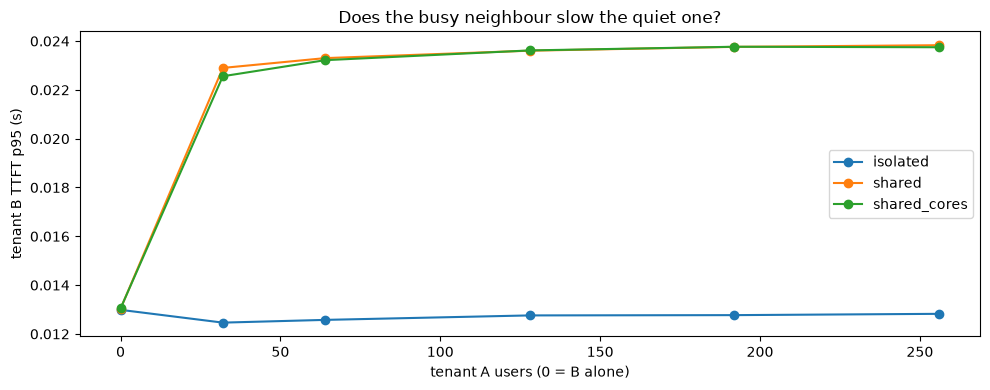

In [4]:
if tenants:
    for s in [x for x in ("isolated", "shared", "shared_cores") if x in tenants]:
        print(f"--- {s}")
        print(f"{'window':<18}{'B TTFT p50':>11}{'B TTFT p95':>11}{'B e2e p95':>10}{'B errors':>9}")
        for w in tenants[s]["metrics"]["windows"]:
            b = w["b"]
            print(f"{w['window']:<18}{cell(b['ttft_s'].get('p50'), '.0f', 11, 1000, 'ms')}{cell(b['ttft_s'].get('p95'), '.0f', 11, 1000, 'ms')}"
                  f"{cell(b['e2e_s'].get('p95'), '.0f', 10, 1000, 'ms')}{b['errors']:>9}")
    fig, ax = plt.subplots(figsize=(10, 4))
    for s in [x for x in ("isolated", "shared", "shared_cores") if x in tenants]:
        ws = tenants[s]["metrics"]["windows"]
        ax.plot([w["a_users"] for w in ws], [w["b"]["ttft_s"].get("p95") for w in ws], "o-", label=s)
    ax.set_xlabel("tenant A users (0 = B alone)"); ax.set_ylabel("tenant B TTFT p95 (s)")
    ax.set_title("Does the busy neighbour slow the quiet one?"); ax.legend()
    plt.tight_layout(); plt.show()

## Cost of sharing

Isolated uses 2 GPUs, shared uses 1. Tenant A's peak output throughput, per GPU, and cost per million output tokens at this machine's price ($1.439/hr for 2 GPUs, so $0.72 per GPU hour). Tenant B runs alongside in every case at no extra cost.

In [5]:
PRICE_PER_GPU_HOUR = 1.439 / 2
print(f"{'scenario':<14}{'GPUs':>5}{'peak tok/s':>12}{'at users':>9}{'per GPU':>9}{'$ per 1M out':>14}")
for s in [x for x in ("isolated", "shared", "shared_cores") if x in sweeps]:
    peak = max(sweeps[s]["metrics"]["steps"], key=lambda x: v(x, "server", "output_tokens_per_s") or 0)
    gpus = 2 if s == "isolated" else 1
    a = v(peak, "server", "output_tokens_per_s")
    cost = gpus * PRICE_PER_GPU_HOUR / (a * 3600 / 1e6)
    print(f"{s:<14}{gpus:>5}{a:>12.0f}{peak['users']:>9}{a / gpus:>9.0f}{cost:>14.4f}")

scenario       GPUs  peak tok/s at users  per GPU  $ per 1M out
isolated          2        7873      128     3936        0.0508
shared            1        3964      128     3964        0.0504
shared_cores      1        3807      128     3807        0.0525


## Autoscaling with KEDA

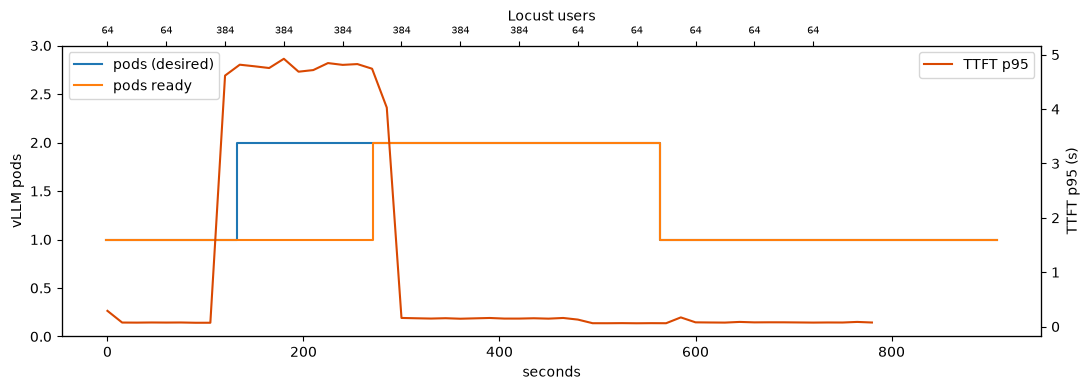

30250 requests, 32 errors
errors at 585 s: 32
Method,Name,Error,Occurrences,First Seen,Last Seen
TOTAL,summarization,Exception('ChunkedEncodingError: Response ended prematurely'),10,2026-10-05T21:35:06Z,2026-10-05T21:35:06Z
TOTAL,multi_turn,Exception('ChunkedEncodingError: Response ended prematurely'),5,2026-10-05T21:35:06Z,2026-10-05T21:35:06Z
TOTAL,long_generation,Exception('ChunkedEncodingError: Response ended prematurely'),16,2026-10-05T21:35:06Z,2026-10-05T21:35:06Z
TOTAL,short_qa,Exception('ChunkedEncodingError: Response ended prematurely'),1,2026-10-05T21:35:06Z,2026-10-05T21:35:06Z

17m         Normal    ScaledObjectReady    scaledobject/vllm-large-scaler                       ScaledObject is ready for scaling
17m         Normal    ScaledObjectReady    scaledobject/vllm-large-scaler                       ScaledObject is ready for scaling
13m         Normal    SuccessfulRescale    horizontalpodautoscaler/keda-hpa-vllm-large-scaler   New size: 2; reason: external metric s0-promet

In [6]:
rep_file = RESULTS / "autoscale" / "replicas.jsonl"
if timeline and rep_file.exists():
    reps = [json.loads(l) for l in rep_file.read_text().splitlines() if l.strip()]
    start = timeline["load"]["start"]
    tl = timeline["metrics"]["timeline"]
    steps, step_s = timeline["load"]["steps"], timeline["load"]["step_seconds"]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.step([r["t"] - start for r in reps], [r["replicas"] for r in reps], where="post", label="pods (desired)")
    ax.step([r["t"] - start for r in reps], [r["ready"] or 0 for r in reps], where="post", label="pods ready")
    ax.set_ylim(0, 3); ax.set_ylabel("vLLM pods"); ax.set_xlabel("seconds")
    ax2 = ax.twinx()
    ax2.plot([b["t_s"] for b in tl], [b["ttft_p95_s"] for b in tl], color="#d94801", label="TTFT p95")
    ax2.set_ylabel("TTFT p95 (s)")
    ax3 = ax.twiny(); ax3.set_xlim(ax.get_xlim())
    ax3.set_xticks([i * step_s for i in range(len(steps))]); ax3.set_xticklabels(steps, fontsize=7); ax3.set_xlabel("Locust users")
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")
    plt.tight_layout(); plt.show()
    print(f"{timeline['metrics']['requests']} requests, {timeline['metrics']['errors']} errors")
    for b in tl:
        if b["errors"]:
            print(f"errors at {b['t_s']:.0f} s: {b['errors']}")
    fails = RESULTS / "autoscale" / "locust_failures.csv"
    if fails.exists():
        print(fails.read_text())
    ev = RESULTS / "autoscale" / "scale_events.txt"
    if ev.exists():
        print("\n".join(l for l in ev.read_text().splitlines() if "SuccessfulRescale" in l or "vllm-large-scaler" in l and "Ready" in l))
else:
    print("No autoscale run.")

## Grafana

The last hour of the session (local time, UTC−4): the shared run (~17:08 to 17:13), shared with core limits (~17:17 to 17:22) and the autoscale run (17:25 to 17:39). The isolated run (17:00 to 17:05) is just before the window. The three single 502s on the errors panel are one per fresh deploy, during the readiness check before measuring; Locust recorded zero failures in all three sharing sweeps.

![Latency](images/07_gpu_slicing_hami/grafana_1_latency.png)

![Traffic](images/07_gpu_slicing_hami/grafana_2_traffic.png)

![Engine capacity](images/07_gpu_slicing_hami/grafana_3_engine_capacity.png)

![GPU](images/07_gpu_slicing_hami/grafana_4_gpu.png)

The new HAMi row. HAMi 2.10 renamed its metrics to `hami_*`, so these panels were fixed during the session (the data was already being scraped):

![GPU sharing (HAMi)](images/07_gpu_slicing_hami/grafana_5_hami.png)

## What happened

**1. HAMi works on RTX 5090 (Blackwell) with no changes, and vLLM respects its memory limit.** With a 20,000 MiB limit, vLLM's `--gpu-memory-utilization 0.90` sized itself to the slice (17.8 GB used) instead of the whole 32 GB card, and the small model fitted in 8.5 GB of its 9,000 MiB. Both ran on GPU 0 while GPU 1 stayed empty. Nothing crashed, and nothing ran out of memory.

**2. Sharing halves the busy model's throughput, but per GPU it costs nothing.** Tenant A peaked at 7,873 output tokens/s on its own GPU and 3,964 when sharing (both at 128 users), with TTFT p95 184 ms instead of 112 ms and inter token latency about twice as long. Per GPU that is 3,936 vs 3,964 tokens/s, and $0.051 vs $0.050 per million output tokens: the isolated setup spent a whole RTX 5090 (and 29 GB of its memory) on a 1.5B model serving 4 clients. **Sharing doesn't create capacity; it stops a small model from wasting a large GPU.**

**3. The quiet neighbour gets slower, but stays steady and fast.** Tenant B's TTFT went from ~10 ms to ~22 ms (p95 13 → 24 ms) as soon as A had any load, and its full answer from 110 ms to ~255 ms. It didn't get worse as A went from 32 to 256 users, and it had zero errors. The two processes take turns on the GPU, so most likely B waits for one A step per B step, and an A step costs about the same whatever A's batch size.

**4. Core limits (70% / 30%) changed nothing measurable.** Tenant A peaked at 3,807 tokens/s against 3,964, and B's latency was identical to plain sharing. HAMi's core limit is a ceiling enforced by throttling kernel launches, not a reservation: most likely, under contention A was already getting about half the GPU, below its 70% cap, and B never wanted more than its 30%, so neither limit ever kicked in. It would matter against a neighbour that tries to take the whole GPU; it isn't a way to buy the quiet tenant lower latency.

**5. KEDA autoscaling works end to end, and the gap is the model's cold start.** When load jumped from 64 to 384 users, KEDA asked for a second pod 12 s later. The pod needed **139 s** to load the model and pass its health check (weights were already on local disk), and for those ~2.5 minutes TTFT p95 sat at ~4.8 s with about 125 requests waiting. Once it was ready, NGINX found it through DNS, TTFT p95 dropped to 0.15 s, and completed requests per 15 s went from ~450 to ~1,000 (2.2×). When load fell back to 64 users, it went back to 1 pod about 80 s later (a 90 s stabilization window, counted from when the metric dropped).

**6. Scaling down dropped 32 streams (0.1% of the run).** All 32 errors came at one moment, 30 s after the scale down: Kubernetes sent the removed pod SIGTERM, waited its default 30 s grace period, then killed it while long answers were still streaming (`ChunkedEncodingError: Response ended prematurely`, mostly long generation and summarization). The fix is a longer `terminationGracePeriodSeconds` with a `preStop` wait so the pod leaves the Service first and finishes its streams. That isn't in this run.

**Recommendation for this hardware:** share a GPU between small models or a small and a large one with HAMi memory limits (no core limits needed), keep big models on whole GPUs, and autoscale on requests inside vLLM with KEDA. Plan for ~2.5 minutes of cold start per new pod (scale out early, or keep a warm minimum), and give vLLM pods a grace period longer than the longest answer.

## Phase 7 exit criteria

- [x] k3s with NVIDIA runtime, HAMi and KEDA installed by one script
- [x] The stack as Kubernetes resources, with Prometheus finding vLLM pods itself
- [x] Isolated, shared and shared with core limits scenarios, with a latency probe for the quiet tenant
- [x] KEDA autoscaling on requests in vLLM
- [x] Phase 7 session on a 2x RTX 5090 machine
- [x] Cost of sharing, noisy neighbour effect and autoscaling behaviour explained